# Week 2 — Preprocessing + Baseline Model

Goal: clean the CICIDS2017 data (duplicates, Inf/NaN, negative values), handle
class imbalance, split train/test, train a baseline Random Forest, and get a
first confusion matrix + per-class precision/recall.

Findings from Week 1 EDA that drive this notebook:
- 2,830,743 rows x 79 cols combined
- 308,381 duplicate rows (~11%)
- 4,376 infinite values (mostly `Flow Bytes/s`, `Flow Packets/s`)
- 1,358 NaN values
- Negative values in `Flow Duration` / `Flow IAT Min` (data glitches)
- Severe class imbalance: BENIGN 2.27M down to Heartbleed=11, Sql Injection=21, Infiltration=36


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
DATA_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
RANDOM_STATE = 42

## 1. Load and combine CSVs

Same loading step as Week 1.

In [2]:
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    df_part = pd.read_csv(f, low_memory=False)
    df_part.columns = df_part.columns.str.strip()
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)

Found 8 CSV files
Combined shape: (2830743, 79)


## 2. Clean the data

Steps, in order:
1. Drop exact duplicate rows
2. Replace Inf/-Inf with NaN, then drop rows with NaN (small enough to just drop rather than impute)
3. Drop rows with negative values in duration/IAT columns (data glitches, not real traffic)
4. Confirm no non-numeric columns remain besides the label


In [3]:
label_col = "Label"
print("Before cleaning:", df.shape)

# 1. Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} remaining")

# 2. Replace Inf with NaN, then drop
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
before = len(df)
df = df.dropna()
print(f"Dropped {before - len(df)} rows with Inf/NaN -> {len(df)} remaining")

# 3. Drop rows with negative values in duration/IAT-type columns (known glitches)
neg_check_cols = [c for c in df.columns if ("Duration" in c or "IAT" in c) and df[c].dtype != object]
before = len(df)
mask_negative = (df[neg_check_cols] < 0).any(axis=1)
df = df[~mask_negative]
print(f"Dropped {before - len(df)} rows with negative duration/IAT values -> {len(df)} remaining")

print("\nFinal cleaned shape:", df.shape)

Before cleaning: (2830743, 79)
Dropped 308381 duplicate rows -> 2522362 remaining
Dropped 1564 rows with Inf/NaN -> 2520798 remaining
Dropped 2880 rows with negative duration/IAT values -> 2517918 remaining

Final cleaned shape: (2517918, 79)


In [4]:
# Confirm only the label column is non-numeric
print(df.dtypes.value_counts())
assert df.drop(columns=[label_col]).select_dtypes(include=['object']).shape[1] == 0, \
    "Found unexpected non-numeric feature columns -- inspect before continuing"
print("\nAll feature columns are numeric. Good to proceed.")

int64      54
float64    24
object      1
Name: count, dtype: int64

All feature columns are numeric. Good to proceed.


## 3. Class distribution after cleaning

Cleaning (especially dropping negative-IAT rows) can shift class counts, so
recheck before deciding on a split/imbalance strategy.


Label
BENIGN                        2092370
DoS Hulk                       172688
DDoS                           127995
PortScan                        90694
DoS GoldenEye                   10281
FTP-Patator                      5927
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3217
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       35
Web Attack � Sql Injection         21
Heartbleed                          7
Name: count, dtype: int64


C:\Users\kimay\AppData\Local\Temp\ipykernel_15032\4215141836.py:9: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


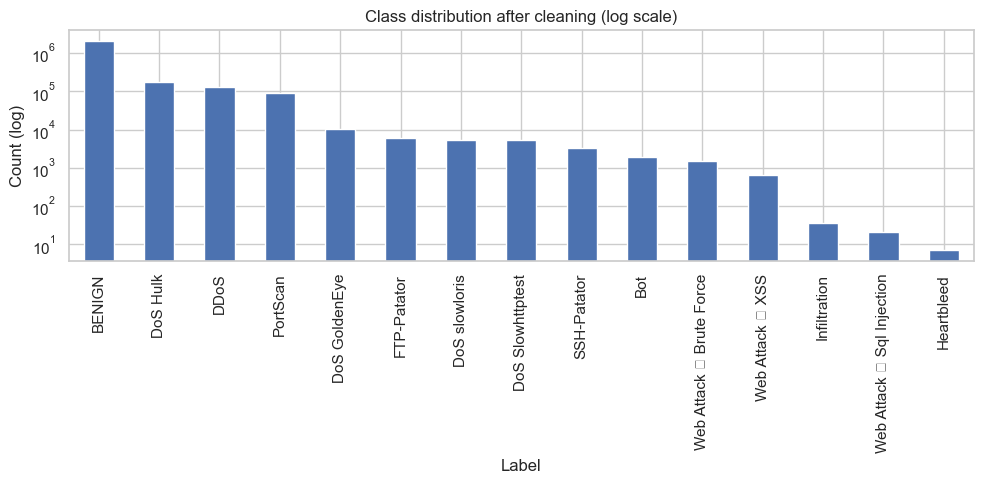

In [5]:
counts = df[label_col].value_counts()
print(counts)

plt.figure(figsize=(10, 5))
counts.plot(kind="bar")
plt.title("Class distribution after cleaning (log scale)")
plt.yscale("log")
plt.ylabel("Count (log)")
plt.tight_layout()
plt.show()

## 4. Handling class imbalance

We start with the simplest approach: **class_weight='balanced'** in the Random
Forest, rather than SMOTE. Reasons:
- SMOTE synthesizes fake samples for extremely rare classes (some have <20
  real examples) — with that few real points, synthetic neighbors are not
  very meaningful and can mislead the model
- `class_weight='balanced'` is simpler, doesn't alter the real data, and is a
  fair baseline to report honestly

If precision/recall on the rare classes is still unusable after this baseline,
we can revisit with SMOTE (or grouping ultra-rare classes into a single
"Rare Attack" bucket) in Week 3 — and report that decision either way rather
than hiding the limitation.

**Note on ultra-rare classes:** Heartbleed, Web Attack - Sql Injection, and
Infiltration have very few samples (originally 11/21/36). Expect near-zero
recall on these regardless of method — that's a genuine dataset limitation,
not a bug in the pipeline.


In [6]:
X = df.drop(columns=[label_col])
y = df[label_col]

print("Feature matrix:", X.shape)
print("Number of classes:", y.nunique())

Feature matrix: (2517918, 78)
Number of classes: 15


## 5. Train/test split

Stratified split so rare classes appear in both train and test sets.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())

Train: (2014334, 78)  Test: (503584, 78)

Train class counts:
Label
BENIGN                        1673896
DoS Hulk                       138150
DDoS                           102396
PortScan                        72555
DoS GoldenEye                    8225
FTP-Patator                      4741
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2574
Bot                              1558
Web Attack � Brute Force         1176
Web Attack � XSS                  522
Infiltration                       28
Web Attack � Sql Injection         17
Heartbleed                          6
Name: count, dtype: int64


In [8]:
# Save processed splits for reuse in Week 3 (avoids re-cleaning every time)
X_train.to_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_test.to_parquet(f"{PROCESSED_DIR}/X_test.parquet")
y_train.to_frame().to_parquet(f"{PROCESSED_DIR}/y_train.parquet")
y_test.to_frame().to_parquet(f"{PROCESSED_DIR}/y_test.parquet")
print("Saved processed train/test splits to", PROCESSED_DIR)

Saved processed train/test splits to ../data/processed


## 6. Train baseline Random Forest

`n_estimators=100` is a reasonable starting point — fast enough for a first
pass on ~2.4M rows. If this is too slow on your machine, drop to 50 first to
confirm the pipeline works end-to-end, then scale back up.

This may take a few minutes depending on your machine — let it run.


In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
rf.fit(X_train, y_train)
print("Training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   48.0s


Training complete.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.8min finished


## 7. Evaluate: confusion matrix + per-class precision/recall

In [10]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred, zero_division=0))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    2.3s finished


Accuracy: 0.9981850098493995
Macro F1: 0.8368205909136933
Weighted F1: 0.9981478546471314

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    418474
                       Bot       0.90      0.72      0.80       390
                      DDoS       1.00      1.00      1.00     25599
             DoS GoldenEye       1.00      0.99      0.99      2056
                  DoS Hulk       1.00      1.00      1.00     34538
          DoS Slowhttptest       0.99      0.99      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.00      0.99      1.00       643
  Web Attack � Brute For

C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


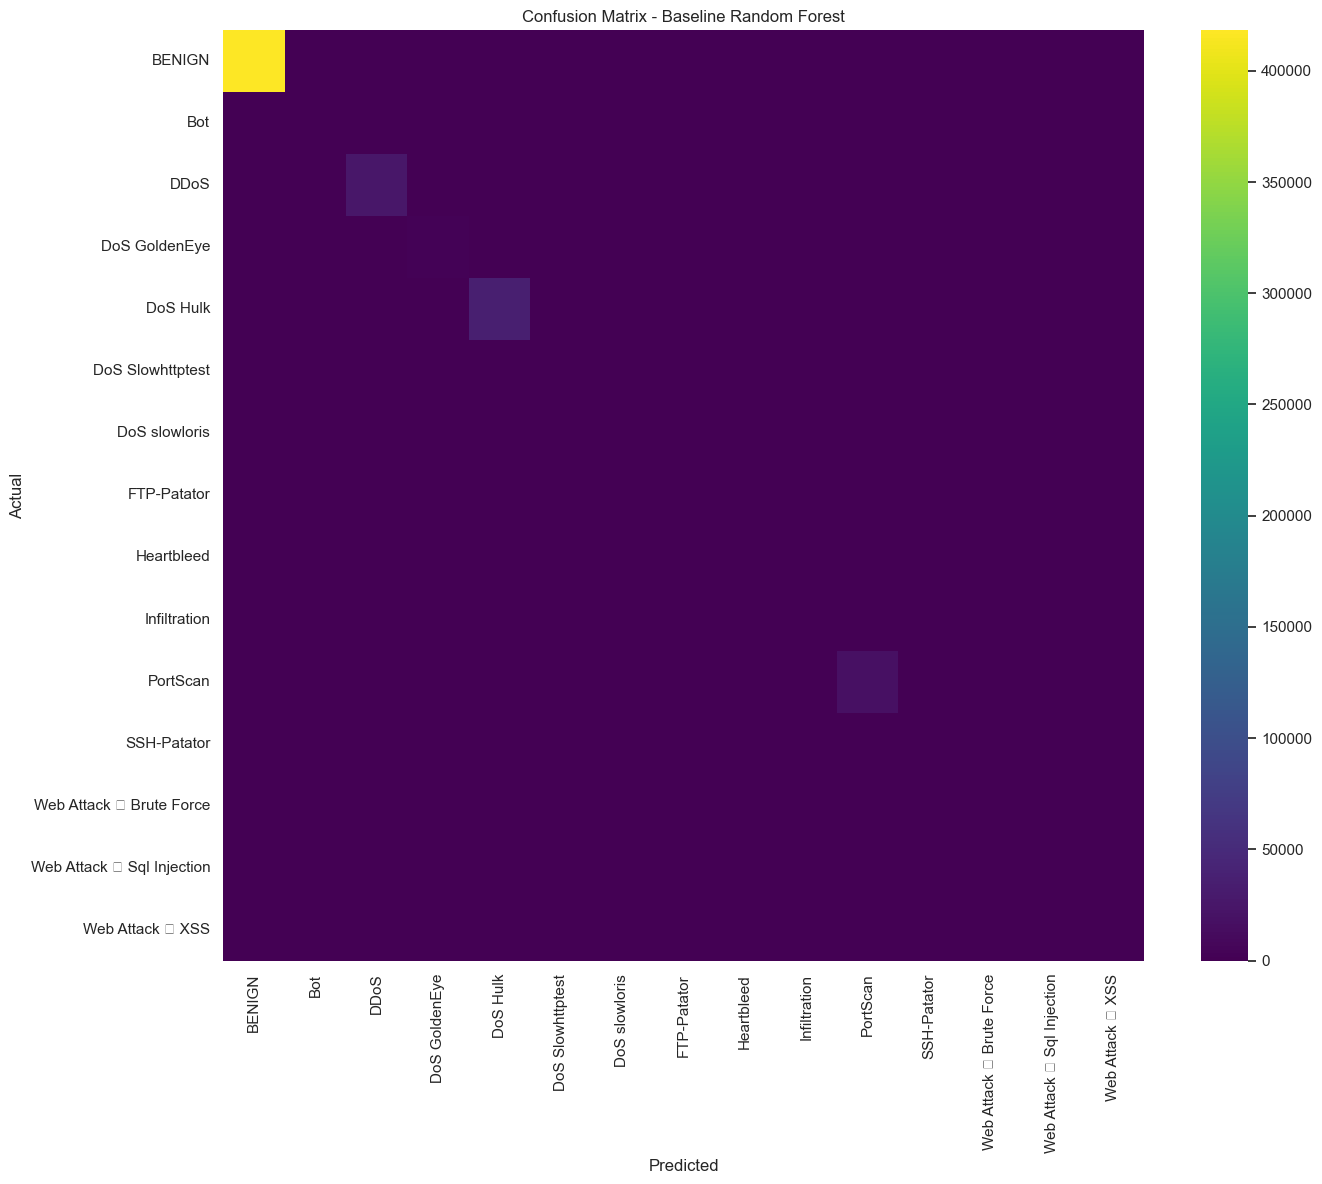

In [11]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="viridis", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Random Forest")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Read this honestly, not optimistically:** accuracy and weighted F1 will
look high mainly because BENIGN and the large attack classes dominate the
dataset. The **macro F1** and the **per-class rows in the classification
report** are what actually show whether rare attacks (Heartbleed, Sql
Injection, Infiltration, Web Attack variants) are being detected at all.
Report both numbers in your writeup, not just accuracy.


## 8. Save the baseline model

In [12]:
joblib.dump(rf, f"{MODELS_DIR}/rf_baseline.joblib")
print(f"Saved model to {MODELS_DIR}/rf_baseline.joblib")

Saved model to ../models/rf_baseline.joblib


## Next steps (Week 3)

- Compare against XGBoost
- Hyperparameter tuning on the better model
- Feature importance analysis
- Decide final handling for ultra-rare classes (keep as-is and report limitation,
  or bucket into "Rare Attack") based on what this baseline's classification
  report shows
